# LAB 3 — ONE-WAY ANOVA TEST (SWEDEN)

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.formula.api import ols

from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import levene

In [69]:
sns.set(style="whitegrid") # Set visualization style

In [70]:
# Load dataset
df = pd.read_csv('WorldEnergy.csv')

# Preview dataset
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (23195, 130)
         country  year iso_code  population  gdp  biofuel_cons_change_pct  \
0  ASEAN (Ember)  2000      NaN         NaN  NaN                      NaN   
1  ASEAN (Ember)  2001      NaN         NaN  NaN                      NaN   
2  ASEAN (Ember)  2002      NaN         NaN  NaN                      NaN   
3  ASEAN (Ember)  2003      NaN         NaN  NaN                      NaN   
4  ASEAN (Ember)  2004      NaN         NaN  NaN                      NaN   

   biofuel_cons_change_twh  biofuel_cons_per_capita  biofuel_consumption  \
0                      NaN                      NaN                  NaN   
1                      NaN                      NaN                  NaN   
2                      NaN                      NaN                  NaN   
3                      NaN                      NaN                  NaN   
4                      NaN                      NaN                  NaN   

   biofuel_elec_per_capita  ...  solar_share_elec  s

In [71]:
df.columns

Index(['country', 'year', 'iso_code', 'population', 'gdp',
       'biofuel_cons_change_pct', 'biofuel_cons_change_twh',
       'biofuel_cons_per_capita', 'biofuel_consumption',
       'biofuel_elec_per_capita',
       ...
       'solar_share_elec', 'solar_share_energy', 'wind_cons_change_pct',
       'wind_cons_change_twh', 'wind_consumption', 'wind_elec_per_capita',
       'wind_electricity', 'wind_energy_per_capita', 'wind_share_elec',
       'wind_share_energy'],
      dtype='object', length=130)

In [72]:
# Create decade variable
df['decade'] = (df['year'] // 10) * 10 
print("\nDecade column created")


Decade column created


# Filter Sweden data

In [96]:
columns_to_keep=['country','year','decade','population','gdp','electricity_demand','electricity_demand_per_capita', 'electricity_generation', 'electricity_share_energy', 'net_elec_imports', 'net_elec_imports_share_demand']
df_Sweden = df.loc[df["country"] == "Sweden",columns_to_keep].copy()

print("\nSweden data filtered")


Sweden data filtered


In [97]:
df_Sweden = df_Sweden.sort_values(by="decade")

# Keep Recent Years (Improves data consistency)

In [98]:
df_Sweden = df_Sweden[df_Sweden["year"] >= 1990].copy()
print("Filtered years from 1990 onwards")

Filtered years from 1990 onwards


# Handle missing values

In [99]:
# Interpolate GDP values
df_Sweden['gdp'] = df_Sweden['gdp'].interpolate(method='linear')

In [100]:
# Remove missing electricity demand
df_Sweden = df_Sweden.dropna(subset=['electricity_demand'])

In [101]:
print("\nCleaned dataset:")
print(df_Sweden.head())


Cleaned dataset:
      country  year  decade  population           gdp  electricity_demand  \
19829  Sweden  1996    1990   8840281.0  2.564989e+11              146.75   
19831  Sweden  1998    1990   8850553.0  2.760407e+11              148.09   
19830  Sweden  1997    1990   8845470.0  2.641711e+11              146.50   
19832  Sweden  1999    1990   8857642.0  2.897028e+11              147.36   
19828  Sweden  1995    1990   8826250.0  2.517411e+11              146.60   

       electricity_demand_per_capita  electricity_generation  \
19829                      16600.150                  140.61   
19831                      16732.287                  158.79   
19830                      16562.150                  149.21   
19832                      16636.482                  154.84   
19828                      16609.547                  148.28   

       electricity_share_energy  net_elec_imports  \
19829                    34.501              6.14   
19831                    38.

In [102]:
print("\nObservations per decade:")
print(df_Sweden.groupby("decade").size())


Observations per decade:
decade
1990    10
2000    10
2010    10
2020     5
dtype: int64


In [103]:
print("\nMean electricity demand per decade:")

print(df_Sweden.groupby("decade")["electricity_demand"].mean())


Mean electricity demand per decade:
decade
1990    145.659
2000    149.362
2010    143.862
2020    140.418
Name: electricity_demand, dtype: float64


In [104]:
print("\nStandard deviation per decade:")

print(df_Sweden.groupby("decade")["electricity_demand"].std())


Standard deviation per decade:
decade
1990    1.683821
2000    3.395225
2010    3.645161
2020    3.311823
Name: electricity_demand, dtype: float64


In [105]:
print("\nTotal observations:", len(df_Sweden))


Total observations: 35


# Visualization (Boxplot)

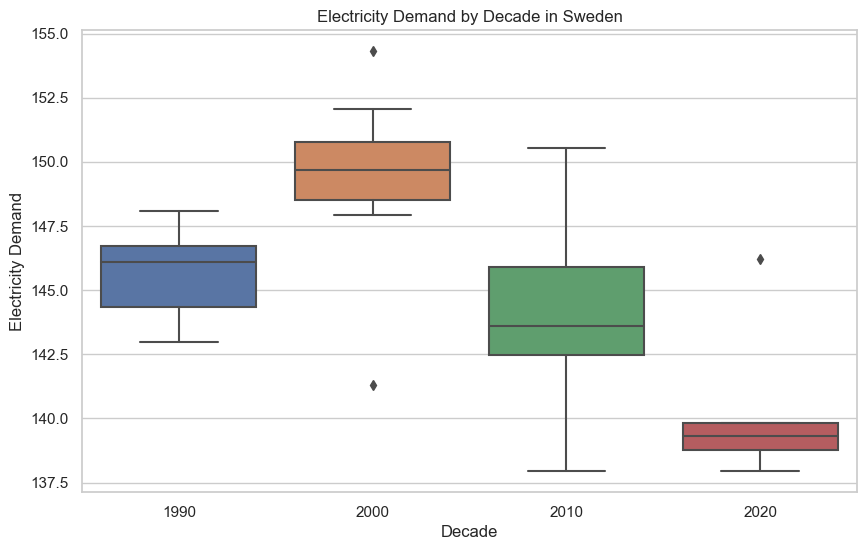

In [106]:
plt.figure(figsize=(10,6))

sns.boxplot(x='decade',y='electricity_demand',data=df_Sweden)

plt.title("Electricity Demand by Decade in Sweden")
plt.xlabel("Decade")
plt.ylabel("Electricity Demand")

plt.show()

# Check Homogeneity of Variance (Levene Test)

In [107]:
groups = [group["electricity_demand"].values
    for name, group in df_Sweden.groupby("decade")]
levene_result = levene(*groups)

print("\nLevene Test Result")
print("Statistic:", levene_result.statistic)
print("P-value:", levene_result.pvalue)

# Interpretation
if levene_result.pvalue > 0.05:
    print("Variance is similar across groups")
else:
    print("Variance is significantly different")


Levene Test Result
Statistic: 0.635983153762667
P-value: 0.5974992131566069
Variance is similar across groups


In [111]:
print("\nNull Hypothesis (H0):")
print("Mean electricity demand is equal across decades")

print("\nAlternative Hypothesis (H1):")
print("At least one decade has different electricity demand")


Null Hypothesis (H0):
Mean electricity demand is equal across decades

Alternative Hypothesis (H1):
At least one decade has different electricity demand


# One-Way ANOVA

In [112]:
model = ols('electricity_demand ~ C(decade)',data=df_Sweden).fit()

anova_table = sm.stats.anova_lm(model,typ=2)

print("\nOne-Way ANOVA Results:")
print(anova_table)
print("\nF-statistic:", anova_table["F"][0])
print("P-value:", p_value)


One-Way ANOVA Results:
               sum_sq    df         F    PR(>F)
C(decade)  305.295984   3.0  10.77718  0.000052
Residual   292.722690  31.0       NaN       NaN

F-statistic: 10.777180173331752
P-value: 5.188382145813073e-05


# Decision Rule

In [109]:
p_value = anova_table["PR(>F)"][0]
alpha = 0.05

print("\nDecision:")

if p_value < alpha:
    print("Reject Null Hypothesis")
    print("There is a significant difference in electricity demand between decades")
else:
    print("Fail to Reject Null Hypothesis")
    print("No significant difference detected")


Decision:
Reject Null Hypothesis
There is a significant difference in electricity demand between decades


# Tukey HSD Post-Hoc Test


Tukey HSD Results:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  1990   2000    3.703 0.0522 -0.0268  7.4328  False
  1990   2010   -1.797 0.5652 -5.5268  1.9328  False
  1990   2020   -5.241 0.0196  -9.809  -0.673   True
  2000   2010     -5.5  0.002 -9.2298 -1.7702   True
  2000   2020   -8.944    0.0 -13.512  -4.376   True
  2010   2020   -3.444 0.1934  -8.012   1.124  False
----------------------------------------------------


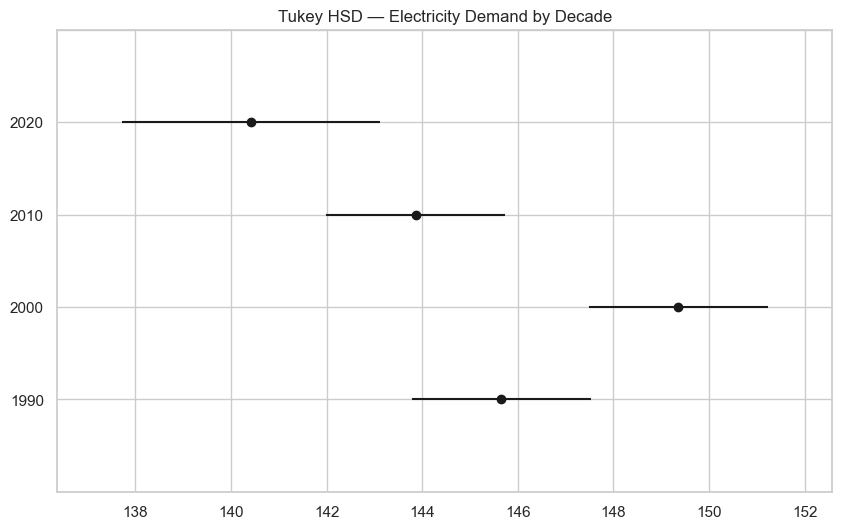

In [110]:
tukey = pairwise_tukeyhsd(
    endog=df_Sweden['electricity_demand'],
    groups=df_Sweden['decade'],
    alpha=0.05
)

print("\nTukey HSD Results:")
print(tukey)

tukey.plot_simultaneous()

plt.title("Tukey HSD — Electricity Demand by Decade")

plt.show()

# Save Clean Dataset

In [91]:
df_Sweden.to_csv("sweden_energy_anova_data.csv",index=False)

print("\nClean dataset saved successfully")


Clean dataset saved successfully
